<div style="text-align: center; margin-top: 200px; margin-bottom: 100px;">

# Machine Learning for Data Analytics  
## Assignment 5  

<br><br>

**Piotr Czech, Filip Miśkiewicz**

</div>

In [1]:
%%html
<style>
img {
    max-width: 1050px !important;
    margin: 20px auto !important;
    display: block !important;
    border: 2px solid #ccc !important;
    padding: 60px 30px !important;
}
</style>

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import (roc_curve, auc, precision_recall_curve,
                             average_precision_score, roc_auc_score)

import os
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid
from torchmetrics.image.fid import FrechetInceptionDistance


import warnings
warnings.filterwarnings('ignore')

In [2]:
random_state = 333
# Reproducibility 
torch.manual_seed(random_state)
np.random.seed(random_state)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Table of Contents

* [Problem 5.1: Variational Autoencoder](#problem-51-variational-autoencoder)
* [Problem 5.2: GAN implementation](#problem-52-gan-implementation)
* [Problem 5.3: Anomaly detection with VAE](#problem-53-anomaly-detection-with-vae)

## Problem 5.1: Variational Autoencoder

### Objective
Implement VAE from scratch in PyTorch.

### Tasks
- Train on Fashion-MNIST dataset.
- Implement reparameterization trick correctly.
- Visualize latent space in 2D using t-SNE.
- Generate new samples by sampling from latent distribution.
- Perform latent space interpolation between pairs of images.

We begin by setting global hyperparameters we will use later.

In [5]:
# Hyperparameters
HIDDEN_DIM  = 512    # neurons in hidden layer
LATENT_DIM  = 20     # dimensionality of latent space
BATCH_SIZE  = 128
NUM_EPOCHS  = 20
LEARNING_RATE = 1e-3

# Fashion-MNIST class labels for plotting
FASHION_LABELS = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

Now we download the Fashion-MNIST dataset. Then we can rescale the pixels values and create separate objects for training and testing.

Train samples: 60,000
Test  samples: 10,000


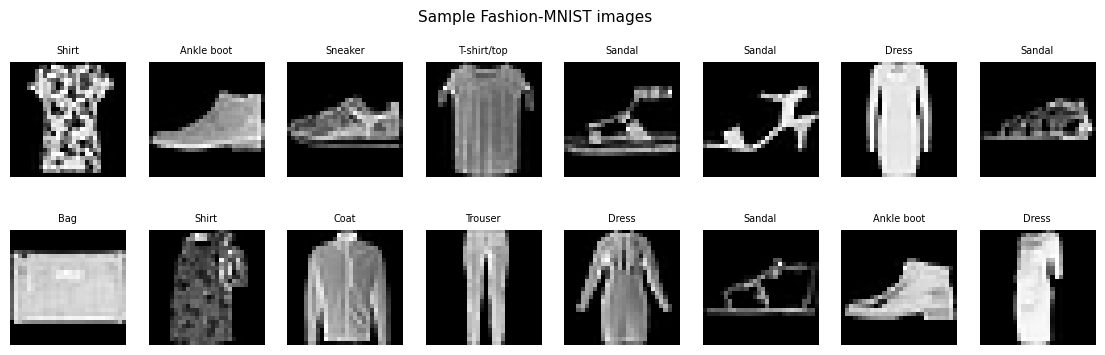

Image tensor shape: torch.Size([1, 28, 28]); value range: [0.00, 1.00]


In [8]:
transform = transforms.Compose([
    transforms.ToTensor(),          # scales pixels to [0.0, 1.0]
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True,  download=True, transform=transform
)
test_dataset  = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train samples: {len(train_dataset):,}')
print(f'Test  samples: {len(test_dataset):,}')

# Visual check
sample_images, sample_labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_images[i].squeeze(), cmap='gray')
    ax.set_title(FASHION_LABELS[sample_labels[i].item()], fontsize=7)
    ax.axis('off')
fig.suptitle('Sample Fashion-MNIST images', fontsize=11)
plt.show()
print(f'Image tensor shape: {sample_images[0].shape}; value range: [{sample_images.min():.2f}, {sample_images.max():.2f}]')

The objects are in poor quality, but still easily recognizable. 

At this moment we can focus on implementing the VAE architecture.

In [10]:
class Encoder(nn.Module):
    """Maps input image x to latent distribution parameters (μ, log σ²)."""

    def __init__(self, input_dim: int, hidden_dim: int, latent_dim: int):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
        )
        self.fc_mu      = nn.Linear(hidden_dim, latent_dim)   # mean
        self.fc_log_var = nn.Linear(hidden_dim, latent_dim)   # log σ²

    def forward(self, x: torch.Tensor):
        h       = self.shared(x)
        mu      = self.fc_mu(h)
        log_var = self.fc_log_var(h)
        return mu, log_var


class Decoder(nn.Module):
    """Reconstructs input image x' from latent vector z."""

    def __init__(self, latent_dim: int, hidden_dim: int, output_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid(),   # pixel values in [0, 1]
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z)


class VAE(nn.Module):
    """Variational Autoencoder combining Encoder, reparameterization, and Decoder."""

    def __init__(self, input_dim: int = 784, hidden_dim: int = 512, latent_dim: int = 20):
        super().__init__()
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, hidden_dim, input_dim)

    # Reparameterization trick
    def reparameterize(self, mu: torch.Tensor, log_var: torch.Tensor) -> torch.Tensor:
        """z = μ + σ·ε  where  ε ~ N(0, I).
        During inference (.eval()) we simply return μ for a deterministic encoding.
        """
        if self.training:
            std = torch.exp(0.5 * log_var)   # σ = exp(0.5 · log σ²)
            eps = torch.randn_like(std)       # ε ~ N(0, 1)
            return mu + std * eps
        return mu

    def forward(self, x: torch.Tensor):
        x_flat     = x.view(x.size(0), -1)            # flatten: (B, 1, 28, 28) → (B, 784)
        mu, log_var = self.encoder(x_flat)             # encode
        z           = self.reparameterize(mu, log_var) # sample latent vector
        x_recon     = self.decoder(z)                  # decode
        return x_recon, mu, log_var


# Instantiate and inspect
vae = VAE(input_dim=784, hidden_dim=HIDDEN_DIM, latent_dim=LATENT_DIM).to(device)
print(vae)
total_params = sum(p.numel() for p in vae.parameters() if p.requires_grad)

print(f'Trainable parameters: {total_params:,}')

VAE(
  (encoder): Encoder(
    (shared): Sequential(
      (0): Linear(in_features=784, out_features=512, bias=True)
      (1): ReLU()
    )
    (fc_mu): Linear(in_features=512, out_features=20, bias=True)
    (fc_log_var): Linear(in_features=512, out_features=20, bias=True)
  )
  (decoder): Decoder(
    (net): Sequential(
      (0): Linear(in_features=20, out_features=512, bias=True)
      (1): ReLU()
      (2): Linear(in_features=512, out_features=784, bias=True)
      (3): Sigmoid()
    )
  )
)
Trainable parameters: 835,384


The VAE is trained by maximising the Evidence Lower BOund (ELBO), which is equivalent to minimising:

$$\mathcal{L} = \underbrace{\mathcal{L}_{\text{recon}}}_{\text{reconstruction}} + \underbrace{\mathcal{L}_{\text{KL}}}_{\text{KL divergence}}$$

- **Reconstruction loss** - binary cross-entropy between the input image and its reconstruction (summed over pixels, averaged over the batch).
- **KL divergence** - regularises the latent space to be close to a standard Gaussian $\mathcal{N}(0, I)$. For a diagonal Gaussian encoder the closed-form KL is:

$$\mathcal{L}_{\text{KL}} = -\frac{1}{2} \sum_{j=1}^{d} \left(1 + \log \sigma_j^2 - \mu_j^2 - e^{\log \sigma_j^2}\right)$$

In [12]:
def vae_loss(x_recon: torch.Tensor,
             x_orig:  torch.Tensor,
             mu:      torch.Tensor,
             log_var: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    VAE loss = Reconstruction loss (BCE) + KL divergence.

    Args:
        x_recon  : decoder output, shape (B, 784), values in [0,1]
        x_orig   : flattened original image, shape (B, 784)
        mu       : encoder mean,    shape (B, latent_dim)
        log_var  : encoder log σ²,  shape (B, latent_dim)

    Returns:
        total_loss, recon_loss, kl_loss  — all scalar tensors
    """
    # Reconstruction: sum over pixels, mean over batch
    recon_loss = nn.functional.binary_cross_entropy(
        x_recon, x_orig, reduction='sum'
    ) / x_orig.size(0)


    kl_loss = -0.5 * torch.sum(
        1 + log_var - mu.pow(2) - log_var.exp()
    ) / x_orig.size(0)

    total_loss = recon_loss + kl_loss
    return total_loss, recon_loss, kl_loss


# Quick check of the loss on a random batch
with torch.no_grad():
    dummy_x = sample_images[:4].to(device)
    xr, mu_t, lv_t = vae(dummy_x)
    total, recon, kl = vae_loss(xr, dummy_x.view(4, -1), mu_t, lv_t)
    print(f'Sanity check losses total: {total:.3f}, recon: {recon:.3f}, KL: {kl:.3f}')

Sanity check losses total: 550.373, recon: 550.229, KL: 0.144


Now we train the VAE. After each epoch we record the average total loss, reconstruction loss, and KL loss on the training set and evaluate on the test set.

In [13]:
optimizer = optim.Adam(vae.parameters(), lr=LEARNING_RATE)

history = {'train_loss': [], 'train_recon': [], 'train_kl': [],
           'test_loss':  [], 'test_recon':  [], 'test_kl':  []}


def run_epoch(loader, train: bool):
    vae.train(train)
    total_l = recon_l = kl_l = 0.0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, _ in loader:
            imgs = imgs.to(device)
            x_flat = imgs.view(imgs.size(0), -1)
            x_recon, mu, log_var = vae(imgs)
            loss, recon, kl = vae_loss(x_recon, x_flat, mu, log_var)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_l += loss.item()
            recon_l += recon.item()
            kl_l    += kl.item()
    n = len(loader)
    return total_l / n, recon_l / n, kl_l / n


print(f'{"Epoch":>6} | {"Train Loss":>12} | {"Train Recon":>12} | {"Train KL":>10} | {"Test Loss":>11}')
print('-' * 65)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_tot, tr_rec, tr_kl = run_epoch(train_loader, train=True)
    te_tot, te_rec, te_kl = run_epoch(test_loader,  train=False)

    history['train_loss'].append(tr_tot);  history['train_recon'].append(tr_rec)
    history['train_kl'].append(tr_kl)
    history['test_loss'].append(te_tot);   history['test_recon'].append(te_rec)
    history['test_kl'].append(te_kl)

    if epoch % 2 == 0 or epoch == 1:
        print(f'{epoch:>6} | {tr_tot:>12.2f} | {tr_rec:>12.2f} | {tr_kl:>10.2f} | {te_tot:>11.2f}')

 Epoch |   Train Loss |  Train Recon |   Train KL |   Test Loss
-----------------------------------------------------------------
     1 |       283.58 |       269.47 |      14.12 |      258.13
     2 |       255.12 |       239.82 |      15.30 |      248.78
     4 |       246.93 |       231.51 |      15.42 |      242.89
     6 |       244.33 |       228.63 |      15.70 |      240.85
     8 |       243.01 |       227.10 |      15.91 |      239.91
    10 |       242.01 |       226.03 |      15.98 |      238.54
    12 |       241.36 |       225.30 |      16.06 |      237.52
    14 |       240.86 |       224.76 |      16.10 |      237.06
    16 |       240.47 |       224.36 |      16.11 |      237.62
    18 |       240.15 |       224.04 |      16.12 |      237.43
    20 |       239.85 |       223.72 |      16.13 |      236.17


Now let's plot the total loss, reconstruction loss, and KL divergence over all epochs for both train and test sets. A well-behaved VAE should show steadily decreasing curves with train and test tracking closely.

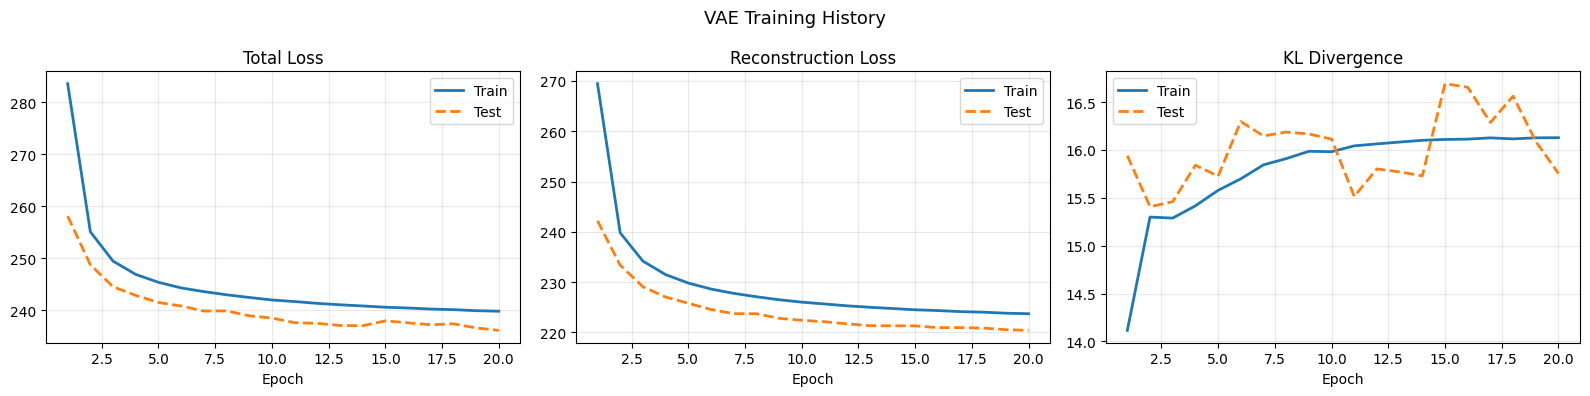

In [14]:
epochs_range = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
pairs = [
    ('Total Loss',         'train_loss',  'test_loss'),
    ('Reconstruction Loss','train_recon', 'test_recon'),
    ('KL Divergence',      'train_kl',   'test_kl'),
]
for ax, (title, trk, tek) in zip(axes, pairs):
    ax.plot(epochs_range, history[trk], label='Train', linewidth=2)
    ax.plot(epochs_range, history[tek], label='Test',  linewidth=2, linestyle='--')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)

fig.suptitle('VAE Training History', fontsize=13)
plt.tight_layout()
plt.show()

The loss curves behave as expected. The KL rises and then stabilises in a moderate range, which means the model found a balance between compression and reconstruction.

Now, we will pass at least 10 test images through the trained VAE and display each original next to its reconstruction.

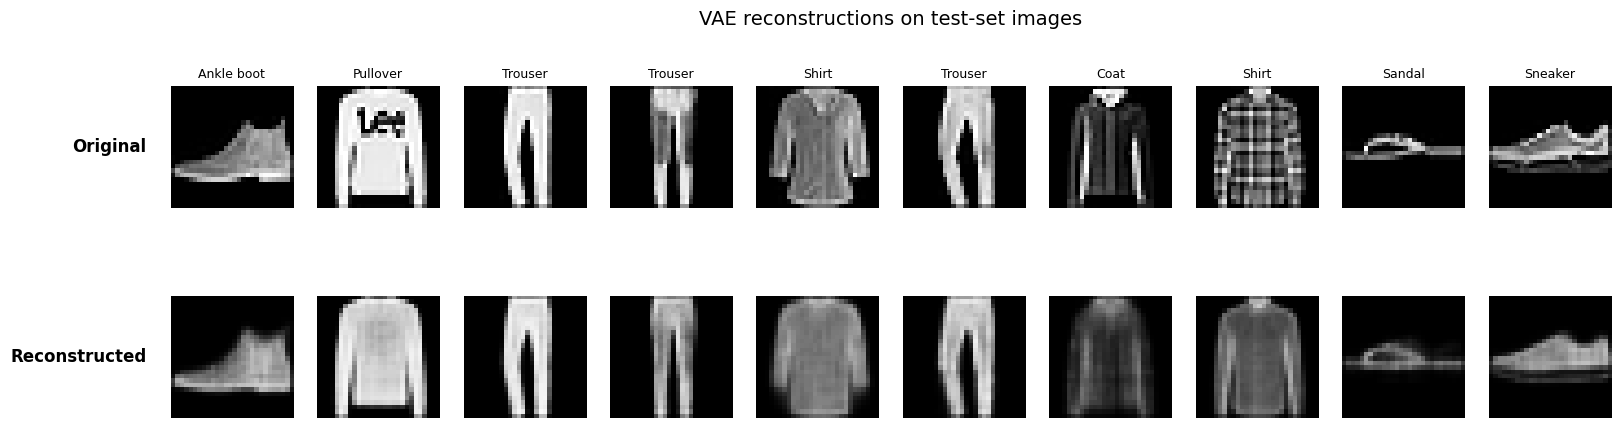

In [28]:
vae.eval()
NUM_SHOW = 10

# Fetch one test batch
test_imgs, test_labels = next(iter(test_loader))
test_imgs = test_imgs[:NUM_SHOW].to(device)

with torch.no_grad():
    x_recon, _, _ = vae(test_imgs)
    x_recon = x_recon.cpu().view(-1, 28, 28)

test_imgs_cpu = test_imgs.cpu().squeeze(1)  # (N, 28, 28)

# Slightly increased height to accommodate labels comfortably
fig, axes = plt.subplots(2, NUM_SHOW, figsize=(18, 5)) 

for i in range(NUM_SHOW):
    # Original Images
    axes[0, i].imshow(test_imgs_cpu[i], cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title(FASHION_LABELS[test_labels[i].item()], fontsize=9)
    axes[0, i].axis('off')

    # Reconstructed Images
    axes[1, i].imshow(x_recon[i], cmap='gray', vmin=0, vmax=1)
    axes[1, i].axis('off')


axes[0, 0].annotate('Original', xy=(-0.2, 0.5), xycoords='axes fraction',
                    va='center', ha='right', fontsize=12, fontweight='bold')

axes[1, 0].annotate('Reconstructed', xy=(-0.2, 0.5), xycoords='axes fraction',
                    va='center', ha='right', fontsize=12, fontweight='bold')

fig.suptitle('VAE reconstructions on test-set images', fontsize=14, y=0.98)

# adjust layout so the left labels don't get cut off
plt.subplots_adjust(left=0.1) 
plt.show()

We can see that the images kept their crucial shapes to be easily recognized after the reconstruction, which means our VAE worked as planned.

Now, to understand the structure learned in latent space we:
1. Pass a large sample of test images (up to 5 000) through the encoder to obtain their mean vectors $\mu_i$.
2. Apply t-SNE (2D) to reduce the `latent_dim`-dimensional $\mu$ vectors to 2D.
3. Colour each point by its Fashion-MNIST class label.

Well-separated clusters would indicate that the VAE has learned a semantically meaningful latent space.

Running t-SNE on 5000 latent vectors of dimension 20 …


c:\Users\filip\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE done.


C:\Users\filip\AppData\Local\Temp\ipykernel_6684\489888454.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', 10)


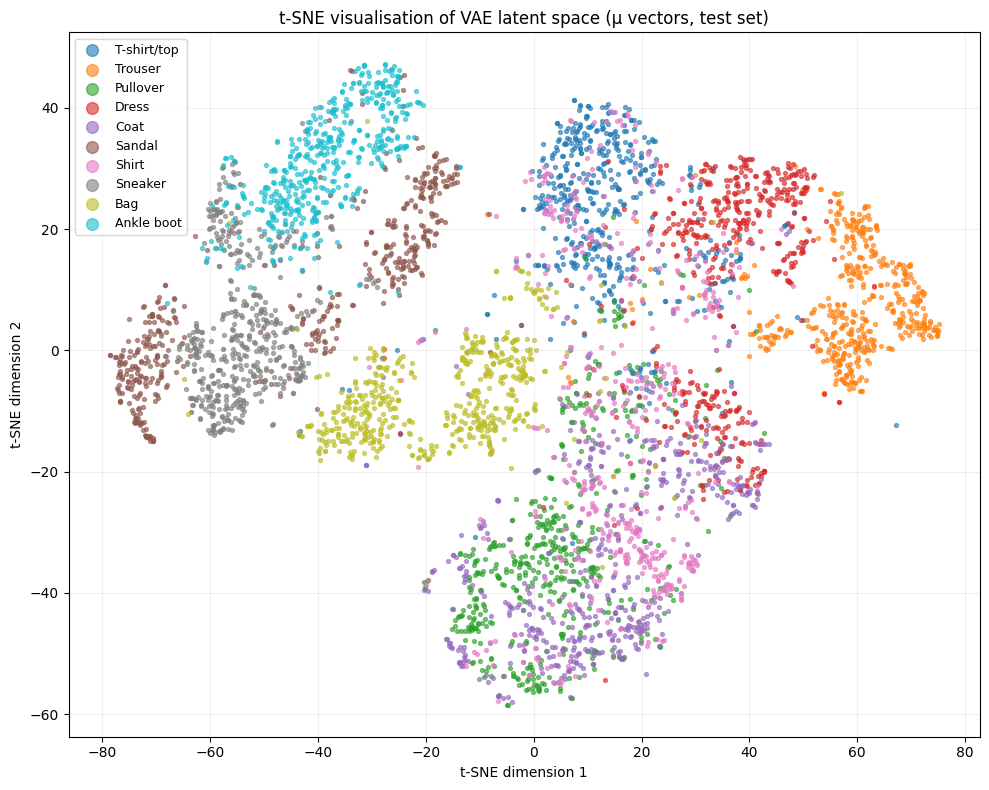

In [29]:
MAX_TSNE = 5000

vae.eval()
all_mu, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        x_flat = imgs.view(imgs.size(0), -1)
        mu, _ = vae.encoder(x_flat)
        all_mu.append(mu.cpu().numpy())
        all_labels.append(labels.numpy())
        if sum(len(m) for m in all_mu) >= MAX_TSNE:
            break

all_mu     = np.concatenate(all_mu,     axis=0)[:MAX_TSNE]
all_labels = np.concatenate(all_labels, axis=0)[:MAX_TSNE]

print(f'Running t-SNE on {len(all_mu)} latent vectors of dimension {LATENT_DIM} …')
tsne   = TSNE(n_components=2, perplexity=40, random_state=random_state, n_iter=1000)
mu_2d  = tsne.fit_transform(all_mu)
print('t-SNE done.')

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
cmap = plt.cm.get_cmap('tab10', 10)
for cls_idx, cls_name in enumerate(FASHION_LABELS):
    mask = all_labels == cls_idx
    ax.scatter(mu_2d[mask, 0], mu_2d[mask, 1],
               s=8, alpha=0.6, color=cmap(cls_idx), label=cls_name)

ax.legend(markerscale=3, fontsize=9, loc='best')
ax.set_title('t-SNE visualisation of VAE latent space (μ vectors, test set)', fontsize=12)
ax.set_xlabel('t-SNE dimension 1')
ax.set_ylabel('t-SNE dimension 2')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Clearly, there is a structure and points within the same class are mostly close to each other. However, there are some classes that occupy similar places and mix with different ones. For example, the shirt and pullover are mixed.

Because the KL divergence regularises the latent space to resemble $\mathcal{N}(0, I)$, we can generate entirely new images by:
1. Sampling a random latent vector $z \sim \mathcal{N}(0, I)$ of size `latent_dim`.
2. Passing it through the decoder to produce a synthetic image $x'$.

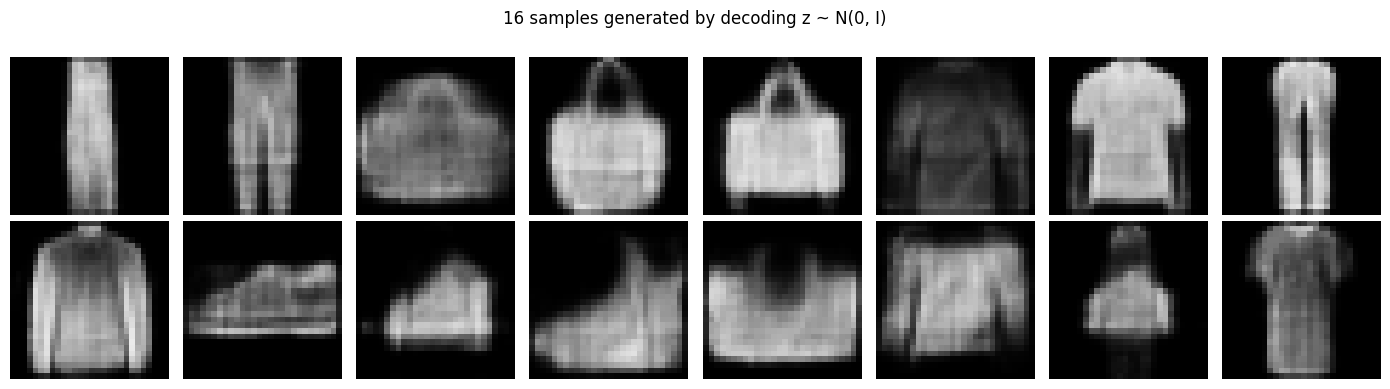

In [30]:
NUM_SAMPLES = 16

vae.eval()
with torch.no_grad():
    z_random = torch.randn(NUM_SAMPLES, LATENT_DIM).to(device)   # z ~ N(0, I)
    generated = vae.decoder(z_random).cpu().view(-1, 28, 28)

cols = 8
rows = NUM_SAMPLES // cols
fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 2))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i], cmap='gray', vmin=0, vmax=1)
    ax.axis('off')

fig.suptitle(f'{NUM_SAMPLES} samples generated by decoding z ~ N(0, I)', fontsize=12)
plt.tight_layout()
plt.show()

The generated samples are mostly recognizable, but some of the images are very noisy.

Because of the smoothnes of the VAE latent space, linearly interpolating between two latent codes produces relevant intermediate images.

For two test images $x_1, x_2$ we:
1. Encode each to get $\mu_1, \mu_2$.
2. For $t \in \{0, 0.2, 0.4, \ldots, 1.0\}$ compute $z(t) = (1-t)\mu_1 + t\,\mu_2$.
3. Decode each $z(t)$ to obtain the interpolated image $x'(t)$.

We do this for 3 pairs of images from different categories.

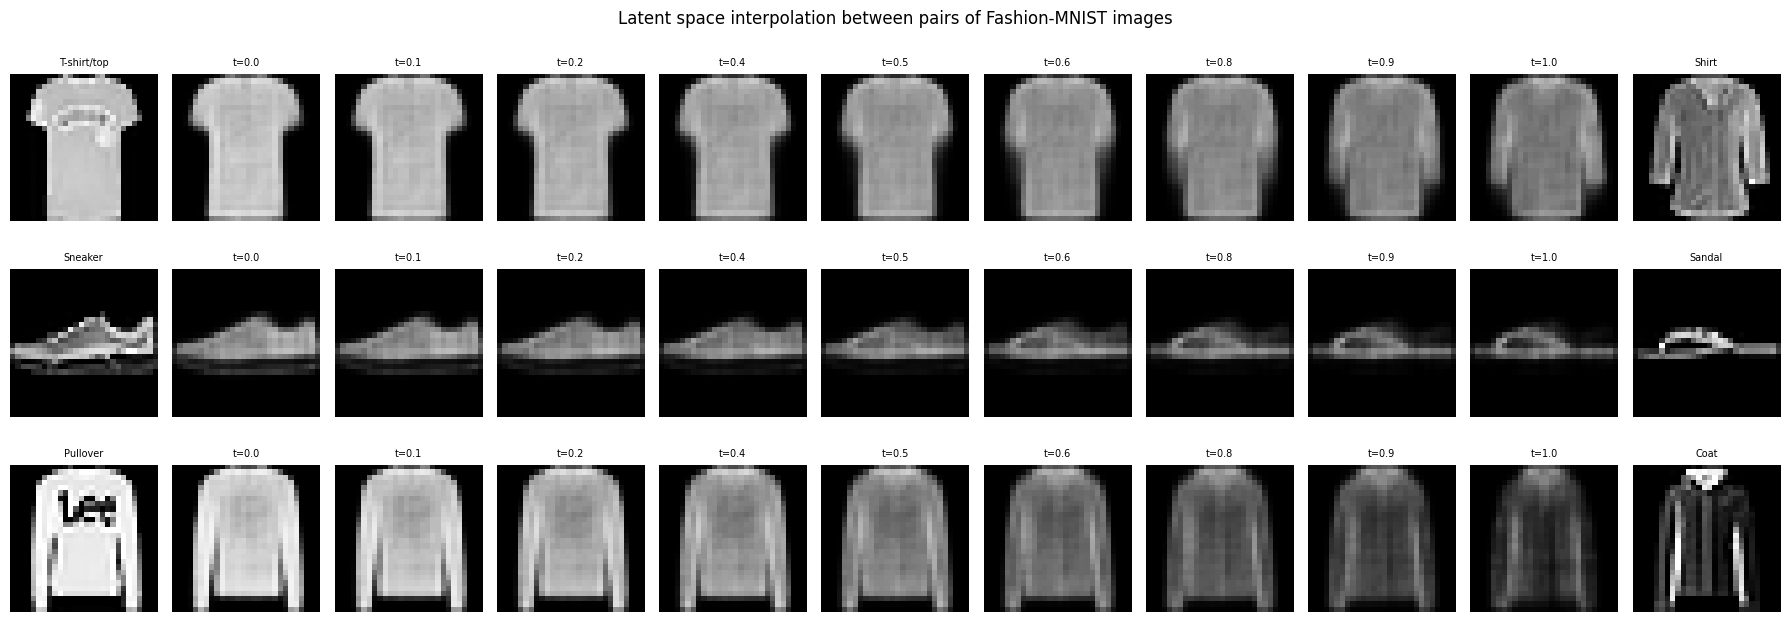

In [32]:
# one image per class from the test set
class_images = {}
for imgs, labels in test_loader:
    for img, lbl in zip(imgs, labels):
        lbl = lbl.item()
        if lbl not in class_images:
            class_images[lbl] = img
    if len(class_images) == 10:
        break


pairs_cfg = [
    (0, 6),   # T-shirt,  Shirt
    (7, 5),   # Sneaker, Sandal
    (2, 4),   # Pullover, Coat
]

N_STEPS = 9
t_values = np.linspace(0, 1, N_STEPS)

vae.eval()
fig, axes = plt.subplots(len(pairs_cfg), N_STEPS + 2, figsize=(18, len(pairs_cfg) * 2.2))

for row, (cls1, cls2) in enumerate(pairs_cfg):
    x1 = class_images[cls1].unsqueeze(0).to(device)
    x2 = class_images[cls2].unsqueeze(0).to(device)

    with torch.no_grad():
        mu1, _ = vae.encoder(x1.view(1, -1))
        mu2, _ = vae.encoder(x2.view(1, -1))

        interp_imgs = []
        for t in t_values:
            z_t = (1 - t) * mu1 + t * mu2
            x_t = vae.decoder(z_t).cpu().view(28, 28)
            interp_imgs.append(x_t)

    # original x1
    ax = axes[row, 0]
    ax.imshow(x1.cpu().squeeze(), cmap='gray', vmin=0, vmax=1)
    ax.set_title(FASHION_LABELS[cls1], fontsize=7)
    ax.axis('off')
    if row == 0: ax.set_xlabel('x₁')

    # interpolations
    for col, (t, img) in enumerate(zip(t_values, interp_imgs), start=1):
        axes[row, col].imshow(img, cmap='gray', vmin=0, vmax=1)
        axes[row, col].set_title(f't={t:.1f}', fontsize=7)
        axes[row, col].axis('off')

    # original x2
    ax = axes[row, -1]
    ax.imshow(x2.cpu().squeeze(), cmap='gray', vmin=0, vmax=1)
    ax.set_title(FASHION_LABELS[cls2], fontsize=7)
    ax.axis('off')

fig.suptitle('Latent space interpolation between pairs of Fashion-MNIST images', fontsize=12)
plt.tight_layout()
plt.show()

In each example, we can observe the smooth transformation between the two classes.

## Problem 5.2: GAN Implementation

### Objective
Build a DCGAN for image generation

### Tasks
- Train on CIFAR-10 dataset.
- Implement proper generator and discriminator architectures.
- Monitor training stability using loss curves and Fréchet Inception Distance.
- Generate grid of synthetic images throughout training.
- Discuss challenges encountered and solutions applied.

The lecture notes say to use CIFAR-10 and rescale pixels to `[-1, 1]`. This matches the `tanh` output of generator.

In [3]:
BATCH_SIZE = 128
NUM_WORKERS = 2

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

len(train_dataset), train_dataset.classes

(50000,
 ['airplane',
  'automobile',
  'bird',
  'cat',
  'deer',
  'dog',
  'frog',
  'horse',
  'ship',
  'truck'])

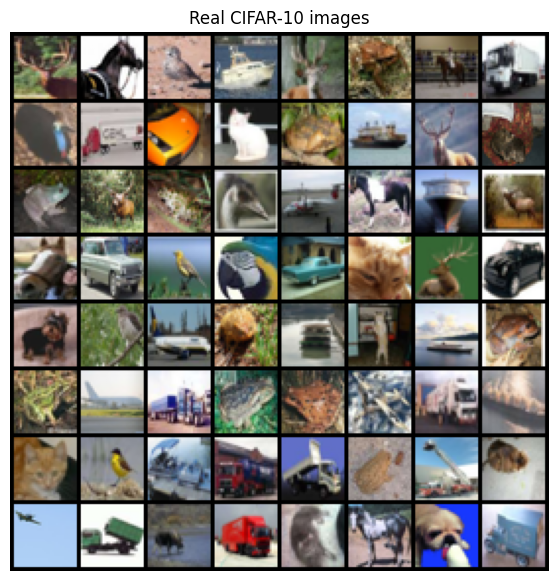

In [ ]:
def denorm(x):
    return (x + 1) / 2


def show_grid(images, title=None, nrow=8):
    grid = make_grid(denorm(images).clamp(0, 1), nrow=nrow, padding=2)
    plt.figure(figsize=(7, 7))
    plt.imshow(grid.permute(1, 2, 0).cpu())
    plt.axis('off')
    if title:
        plt.title(title)
    plt.show()


real_batch, _ = next(iter(train_loader))
show_grid(real_batch[:64], 'Real CIFAR-10 images')

Generator starts from a latent vector `z` of size 100. Then transposed convolutions grow it from `1x1` to `32x32` image. We use batch normalization and ReLU, and in final layer `tanh`.

In [7]:
NZ = 100 # size of latent vector z, dimention of entry noise
NGF = 128 # number of generator feature maps
NDF = 128 # number of discriminator feature maps, bazowa liczba kanałów w discriminatorze
NC = 3 # number of channels in images

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(NZ, NGF * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(NGF * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(NGF * 4, NGF * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NGF * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(NGF * 2, NGF, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NGF),
            nn.ReLU(True),
            nn.ConvTranspose2d(NGF, NC, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        return self.net(z)

Discriminator works in opposite direction. It compresses `3x32x32` image to one probability. First and last layer do not use batch normalization, like in DCGAN notes.

In [6]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(NC, NDF, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(NDF, NDF * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NDF * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(NDF * 2, NDF * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(NDF * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(NDF * 4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x).view(-1)

Weights are initialized from normal distribution. This small detail is important for GANs, because bad start can make one network dominate too early.

In [8]:
def weights_init(m):
    name = m.__class__.__name__
    if 'Conv' in name:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in name:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


generator = Generator().to(device)
discriminator = Discriminator().to(device)
generator.apply(weights_init)
discriminator.apply(weights_init)

g_params = sum(p.numel() for p in generator.parameters())
d_params = sum(p.numel() for p in discriminator.parameters())
print(f'Generator parameters: {g_params:,}')
print(f'Discriminator parameters: {d_params:,}')

Generator parameters: 3,448,576
Discriminator parameters: 2,637,312


We use binary cross entropy and two Adam optimizers. The learning rate `0.0002` and `beta1=0.5` are standard DCGAN values from notes.

In [9]:
NUM_EPOCHS = 50
LR = 0.0002
BETA1 = 0.5
FID_EVERY = 5
FID_BATCHES = 20

criterion = nn.BCELoss()
optimizer_g = optim.Adam(generator.parameters(), lr=LR, betas=(BETA1, 0.999))
optimizer_d = optim.Adam(discriminator.parameters(), lr=LR, betas=(BETA1, 0.999))

fixed_noise = torch.randn(64, NZ, 1, 1, device=device)

For FID we compare real CIFAR images with generated images. To keep notebook practical, we calculate it on a subset of batches, so the value is approximate but still useful for monitoring.

In [10]:
def calculate_fid(generator, loader, n_batches=FID_BATCHES):
    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
    generator.eval()
    with torch.no_grad():
        for i, (real, _) in enumerate(loader):
            if i >= n_batches:
                break

            real = denorm(real.to(device)).clamp(0, 1)
            noise = torch.randn(real.size(0), NZ, 1, 1, device=device)
            fake = denorm(generator(noise)).clamp(0, 1)

            fid.update(real, real=True)
            fid.update(fake, real=False)

    generator.train()
    return float(fid.compute().detach().cpu())

Each training step has two phases. First discriminator learns to give high scores to real images and low scores to fake images. Then generator is updated to fool discriminator.

In [11]:
history = {'g_loss': [], 'd_loss': []}
fid_history = []
snapshots = {}

for epoch in range(1, NUM_EPOCHS + 1):
    generator.train()
    discriminator.train()
    epoch_g_loss, epoch_d_loss = 0.0, 0.0

    for real, _ in train_loader:
        real = real.to(device)
        b_size = real.size(0)

        # Train discriminator
        optimizer_d.zero_grad(set_to_none=True)
        labels_real = torch.ones(b_size, device=device)
        labels_fake = torch.zeros(b_size, device=device)

        out_real = discriminator(real)
        loss_real = criterion(out_real, labels_real)

        noise = torch.randn(b_size, NZ, 1, 1, device=device)
        fake = generator(noise)
        out_fake = discriminator(fake.detach())
        loss_fake = criterion(out_fake, labels_fake)

        d_loss = loss_real + loss_fake
        d_loss.backward()
        optimizer_d.step()

        # Train generator
        optimizer_g.zero_grad(set_to_none=True)
        out_fake_for_g = discriminator(fake)
        g_loss = criterion(out_fake_for_g, labels_real)
        g_loss.backward()
        optimizer_g.step()

        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()

    avg_d = epoch_d_loss / len(train_loader)
    avg_g = epoch_g_loss / len(train_loader)
    history['d_loss'].append(avg_d)
    history['g_loss'].append(avg_g)

    with torch.no_grad():
        snapshots[epoch] = generator(fixed_noise).detach().cpu()

    fid_text = ''
    if epoch == 1 or epoch % FID_EVERY == 0 or epoch == NUM_EPOCHS:
        fid_value = calculate_fid(generator, train_loader)
        fid_history.append((epoch, fid_value))
        fid_text = f' | FID: {fid_value:.2f}'

    print(f'Epoch {epoch:02d}/{NUM_EPOCHS} | D loss: {avg_d:.4f} | G loss: {avg_g:.4f}{fid_text}')

Epoch 01/50 | D loss: 0.4683 | G loss: 6.3635 | FID: 299.36
Epoch 02/50 | D loss: 0.4220 | G loss: 4.6773
Epoch 03/50 | D loss: 0.6253 | G loss: 3.9856
Epoch 04/50 | D loss: 0.4845 | G loss: 3.5571
Epoch 05/50 | D loss: 0.5627 | G loss: 3.4682 | FID: 146.64
Epoch 06/50 | D loss: 0.6901 | G loss: 2.9327
Epoch 07/50 | D loss: 0.7414 | G loss: 2.8445
Epoch 08/50 | D loss: 0.7508 | G loss: 2.6738
Epoch 09/50 | D loss: 0.7544 | G loss: 2.6293
Epoch 10/50 | D loss: 0.7541 | G loss: 2.4444 | FID: 100.92
Epoch 11/50 | D loss: 0.7328 | G loss: 2.5720
Epoch 12/50 | D loss: 0.7640 | G loss: 2.4825
Epoch 13/50 | D loss: 0.7492 | G loss: 2.3364
Epoch 14/50 | D loss: 0.8162 | G loss: 2.2688
Epoch 15/50 | D loss: 0.8279 | G loss: 2.2486 | FID: 68.95
Epoch 16/50 | D loss: 0.7910 | G loss: 2.2485
Epoch 17/50 | D loss: 0.7763 | G loss: 2.2504
Epoch 18/50 | D loss: 0.8165 | G loss: 2.2242
Epoch 19/50 | D loss: 0.8227 | G loss: 2.2357
Epoch 20/50 | D loss: 0.7768 | G loss: 2.2102 | FID: 63.87
Epoch 21/50 

Loss curves in GAN are not expected to decrease like in supervised learning. We mainly check if one network did not completely overpower the other.

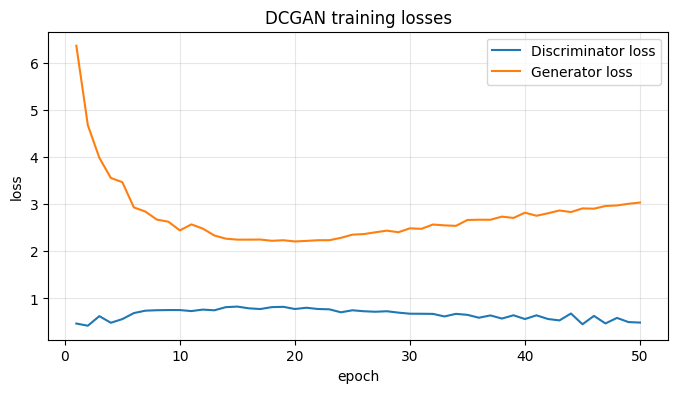

In [12]:
epochs = np.arange(1, NUM_EPOCHS + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, history['d_loss'], label='Discriminator loss')
plt.plot(epochs, history['g_loss'], label='Generator loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('DCGAN training losses')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

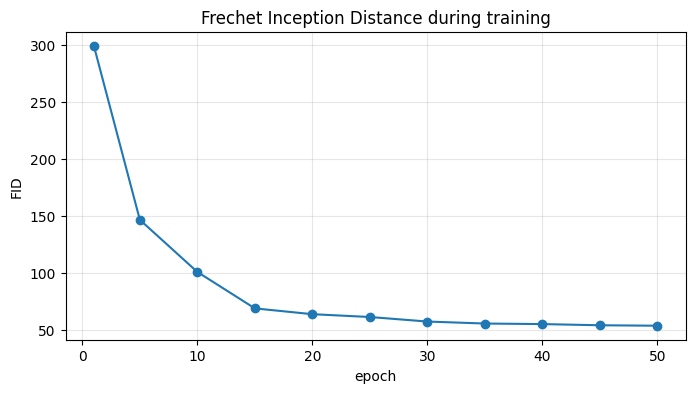

[(1, 299.36199951171875),
 (5, 146.64100646972656),
 (10, 100.91632843017578),
 (15, 68.95293426513672),
 (20, 63.86624526977539),
 (25, 61.389835357666016),
 (30, 57.41321563720703),
 (35, 55.66986846923828),
 (40, 55.18571472167969),
 (45, 54.145835876464844),
 (50, 53.74870300292969)]

In [13]:
fid_epochs, fid_values = zip(*fid_history)

plt.figure(figsize=(8, 4))
plt.plot(fid_epochs, fid_values, marker='o')
plt.xlabel('epoch')
plt.ylabel('FID')
plt.title('Frechet Inception Distance during training')
plt.grid(alpha=0.3)
plt.show()

list(fid_history)

Now we use the same fixed noise vectors to see how generator changed during training. This is better than random examples, because every row shows progress for the same latent points.

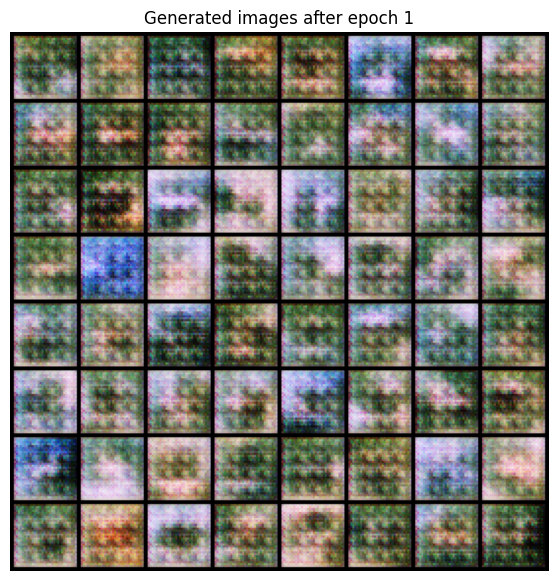

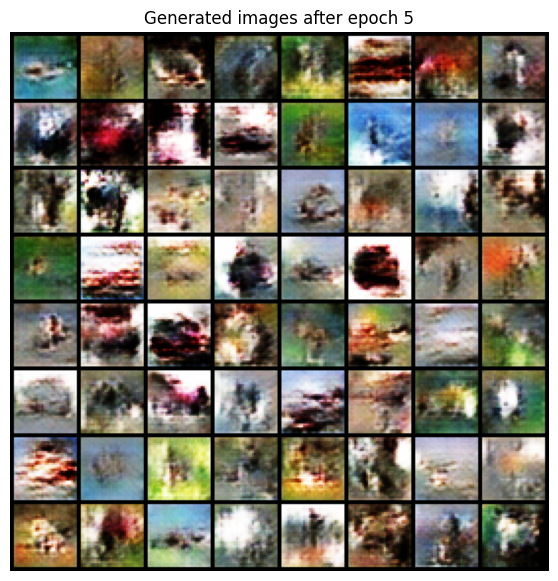

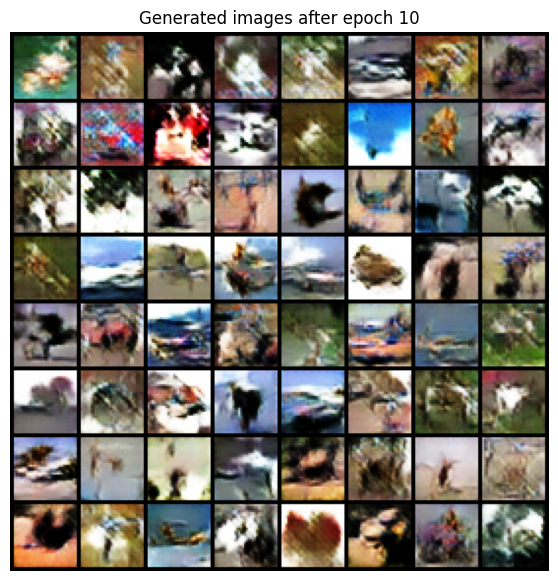

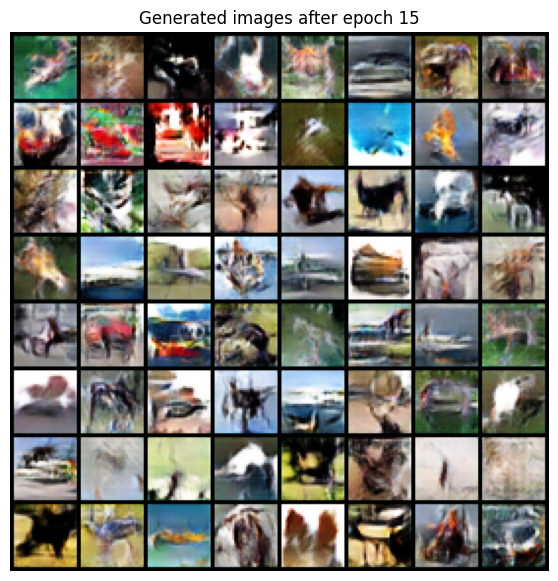

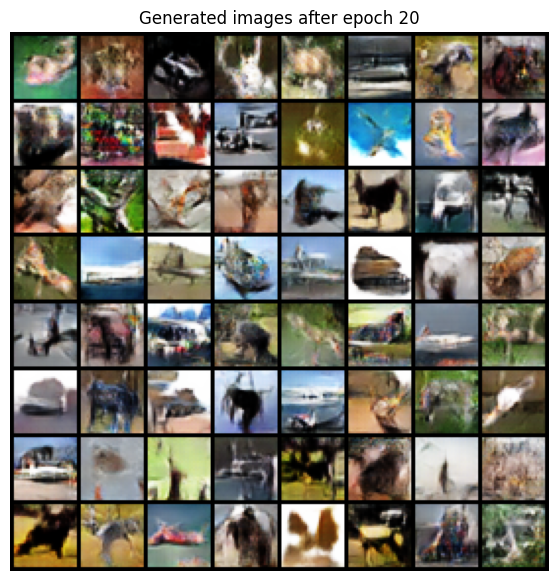

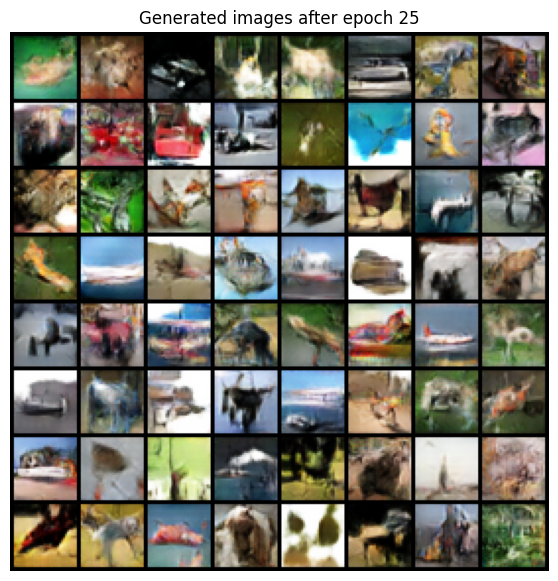

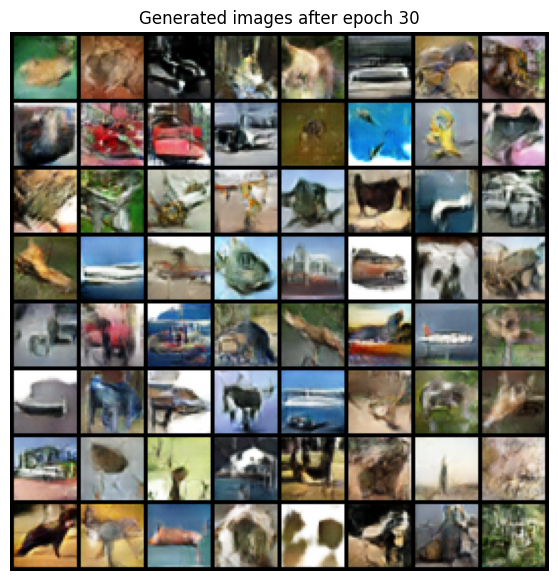

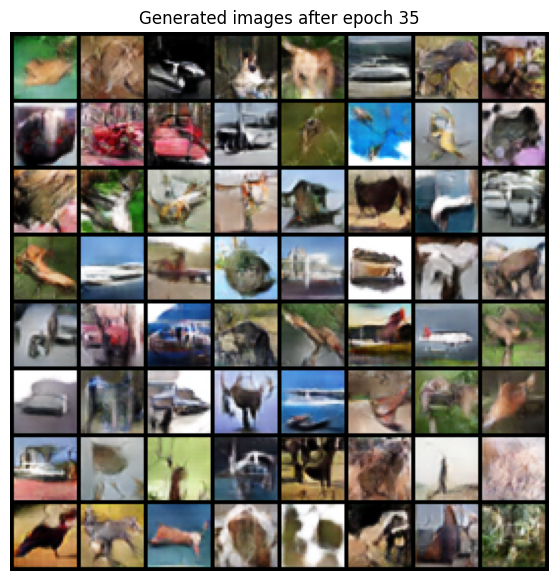

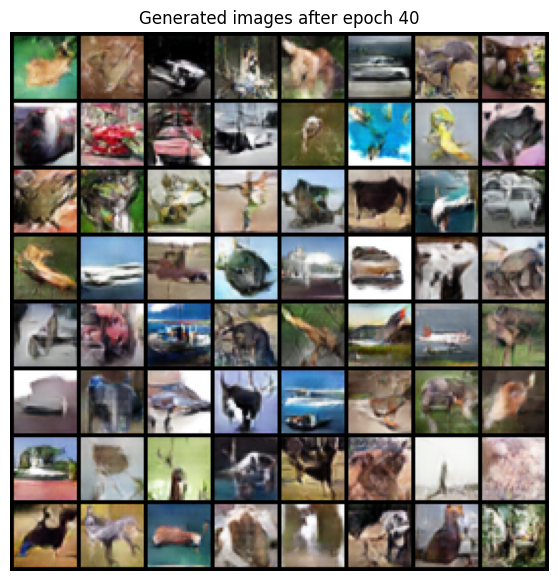

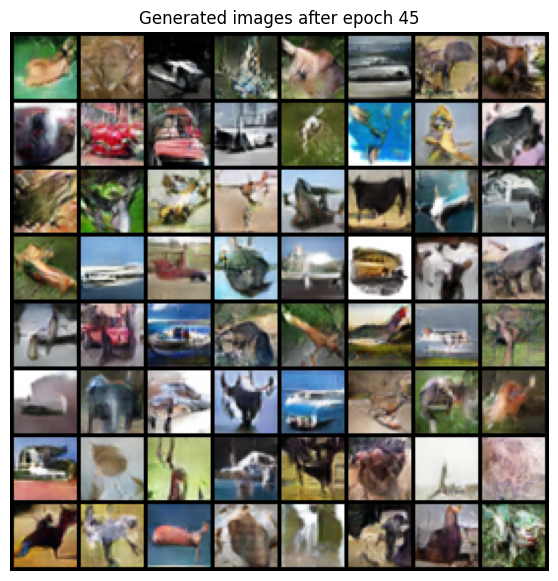

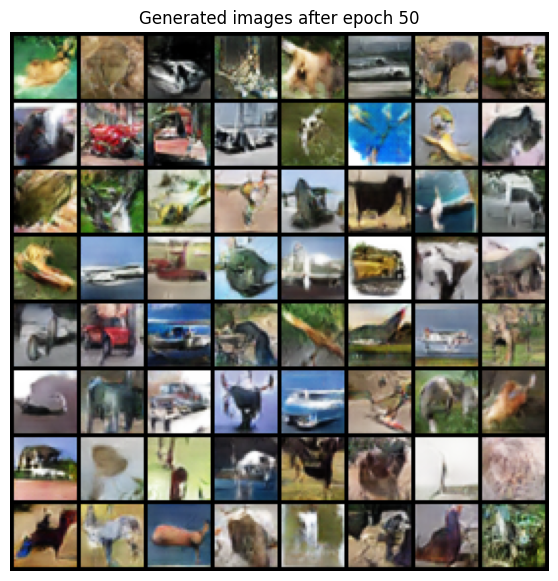

In [14]:
epochs_to_show = [1] + list(range(FID_EVERY, NUM_EPOCHS + 1, FID_EVERY))
epochs_to_show = [e for e in epochs_to_show if e in snapshots]

for epoch in epochs_to_show:
    show_grid(snapshots[epoch], title=f'Generated images after epoch {epoch}')

Finally we generate new images using fresh noise. These samples were not used in monitoring, so they show final generator behaviour on different latent vectors.

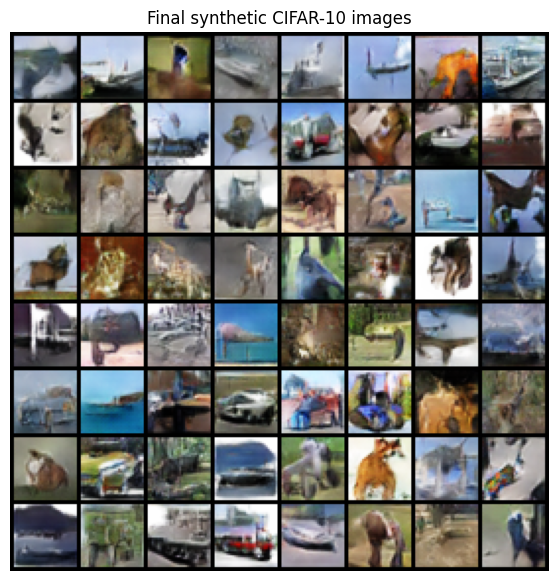

In [15]:
generator.eval()
with torch.no_grad():
    new_noise = torch.randn(64, NZ, 1, 1, device=device)
    final_images = generator(new_noise).cpu()

show_grid(final_images, 'Final synthetic CIFAR-10 images')

GAN training was unstable by nature, because the generator and discriminator optimize opposite objectives. I used the standard DCGAN setup to improve stability: normalization to `[-1, 1]`, `tanh` generator output, batch normalization, normal weight initialization, and Adam with a small learning rate and `beta1 = 0.5`.

The results improved over training. At epoch 1, generated images looked mostly like noise. By epoch 50, they contained more coherent CIFAR-10-like colors and shapes, although the samples were still blurry and sometimes ambiguous.

FID decreased from about 300 to about 54, with most improvement happening during the first 20-30 epochs. After that, the curve mostly flattened. The final grid did not show clear severe mode collapse, because the generated samples remained diverse, but the overall quality was still limited.

## Problem 5.3: Anomaly detection with VAE

### Objective
Use VAE for unsupervised anomaly detection.

### Tasks
- Train VAE on normal samples from credit card fraud dataset.
- Use reconstruction error as anomaly score.
- Compare with traditional anomaly detection methods (Isolation Forest,
One-Class SVM).
- Evaluate using precision-recall curves and ROC-AUC.

We start with loading and preprocessing the Creditcard Fraud Detection dataset from Kaggle: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud?resource=download.

In [20]:
CSV_PATH = '../datasets/creditcard.csv'
df = pd.read_csv(CSV_PATH)

df.drop(columns=['Time'], inplace=True) # uninformative for anomaly detection
print(f'Dataset shape: {df.shape}')
print(f'Normal (0): {(df.Class==0).sum():,}')
print(f'Fraud (1): {(df.Class==1).sum():,}  ({(df.Class==1).mean()*100:.2f} %)')

df.head()

Dataset shape: (284807, 30)
Normal (0): 284,315
Fraud (1): 492  (0.17 %)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


We now split the data and scale features using StandardScaler fit only on the training normals to avoid data leakage.

In [10]:
normal_df = df[df.Class == 0].sample(frac=1, random_state=random_state)
fraud_df  = df[df.Class == 1]

n_train = int(0.8 * len(normal_df))
train_df = normal_df.iloc[:n_train]
test_df  = pd.concat([normal_df.iloc[n_train:], fraud_df], ignore_index=True)

X_train = train_df.drop('Class', axis=1).values
y_train = train_df['Class'].values           # all zeros

X_test  = test_df.drop('Class', axis=1).values
y_test  = test_df['Class'].values

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)      # fit on train normals only
X_test  = scaler.transform(X_test)

print(f'Train: {X_train.shape} (all normal)')
print(f'Test: {X_test.shape} ({(y_test==0).sum():,} normal + {(y_test==1).sum()} fraud)')

Train: (227452, 29) (all normal)
Test: (57355, 29) (56,863 normal + 492 fraud)


We mostly re-use the architecture from Task 1. However, the VAE here differs in two important ways. Input is a 29-dimensional tabular feature vector, not an image, so we use fully-connected layers throughout. The reconstructed features are real-v, standarised values, so we use a linear final layer and MSE as the reconstruction loss instead of BCE.

In [21]:
class EncoderTabular(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(),
        )
        self.fc_mu      = nn.Linear(hidden_dim // 2, latent_dim)
        self.fc_log_var = nn.Linear(hidden_dim // 2, latent_dim)

    def forward(self, x):
        h = self.shared(x)
        return self.fc_mu(h), self.fc_log_var(h)


class DecoderTabular(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim // 2), nn.ReLU(),
            nn.Linear(hidden_dim // 2, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),       # linear — no sigmoid
        )

    def forward(self, z):
        return self.net(z)


class VAETabular(nn.Module):
    def __init__(self, input_dim=29, hidden_dim=128, latent_dim=8):
        super().__init__()
        self.encoder = EncoderTabular(input_dim, hidden_dim, latent_dim)
        self.decoder = DecoderTabular(latent_dim, hidden_dim, input_dim)

    def reparameterize(self, mu, log_var):
        if self.training:
            std = torch.exp(0.5 * log_var)
            return mu + std * torch.randn_like(std)
        return mu

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z = self.reparameterize(mu, log_var)
        x_recon = self.decoder(z)
        return x_recon, mu, log_var


def vae_loss_tabular(x_recon, x_orig, mu, log_var, kl_weight=1.0):
    recon = nn.functional.mse_loss(x_recon, x_orig, reduction='sum') / x_orig.size(0)
    kl    = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / x_orig.size(0)
    return recon + kl_weight * kl, recon, kl

In [22]:
INPUT_DIM_TAB  = X_train.shape[1]   # 29
HIDDEN_DIM_TAB = 128
LATENT_DIM_TAB = 8
BATCH_TAB      = 256
EPOCHS_TAB     = 30
LR_TAB         = 1e-3

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Input dim: {INPUT_DIM_TAB}, hidden: {HIDDEN_DIM_TAB}, latent: {LATENT_DIM_TAB}')
print(f'Device: {device}')

vae_tab = VAETabular(INPUT_DIM_TAB, HIDDEN_DIM_TAB, LATENT_DIM_TAB).to(device)
total_params = sum(p.numel() for p in vae_tab.parameters())
print(f'Parameters: {total_params:,}')
print(vae_tab)

Input dim: 29, hidden: 128, latent: 8
Device: cuda
Parameters: 25,773
VAETabular(
  (encoder): EncoderTabular(
    (shared): Sequential(
      (0): Linear(in_features=29, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=64, bias=True)
      (3): ReLU()
    )
    (fc_mu): Linear(in_features=64, out_features=8, bias=True)
    (fc_log_var): Linear(in_features=64, out_features=8, bias=True)
  )
  (decoder): DecoderTabular(
    (net): Sequential(
      (0): Linear(in_features=8, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=128, bias=True)
      (3): ReLU()
      (4): Linear(in_features=128, out_features=29, bias=True)
    )
  )
)


We train the VAE exclusively on the normal training samples so the VAE learns to reconstruct normal patterns well. Fraud transactions, will later produce high reconstruction errors, which will serve us as our anomaly score.

In [23]:
X_train_t = torch.FloatTensor(X_train)
train_ds_tab = TensorDataset(X_train_t)
train_dl_tab = DataLoader(train_ds_tab, batch_size=BATCH_TAB, shuffle=True)

optimizer_tab = optim.Adam(vae_tab.parameters(), lr=LR_TAB)
scheduler_tab = optim.lr_scheduler.StepLR(optimizer_tab, step_size=10, gamma=0.5)

history_tab = {'loss': [], 'recon': [], 'kl': []}

for epoch in range(1, EPOCHS_TAB + 1):
    vae_tab.train()
    ep_loss = ep_recon = ep_kl = 0.0
    for (xb,) in train_dl_tab:
        xb = xb.to(device)
        x_recon, mu, log_var = vae_tab(xb)
        loss, recon, kl = vae_loss_tabular(x_recon, xb, mu, log_var)
        optimizer_tab.zero_grad()
        loss.backward()
        optimizer_tab.step()
        ep_loss  += loss.item()
        ep_recon += recon.item()
        ep_kl    += kl.item()

    scheduler_tab.step()
    n = len(train_dl_tab)
    history_tab['loss'].append(ep_loss / n)
    history_tab['recon'].append(ep_recon / n)
    history_tab['kl'].append(ep_kl / n)

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch: {epoch}, loss={ep_loss/n:.4f}, recon={ep_recon/n:.4f}, kl={ep_kl/n:.4f}')

Epoch: 1, loss=22.9510, recon=19.3695, kl=3.5815
Epoch: 5, loss=16.3989, recon=9.8444, kl=6.5544
Epoch: 10, loss=15.4320, recon=8.4204, kl=7.0115
Epoch: 15, loss=14.9313, recon=7.7784, kl=7.1529
Epoch: 20, loss=14.7300, recon=7.5230, kl=7.2070
Epoch: 25, loss=14.5735, recon=7.3355, kl=7.2380
Epoch: 30, loss=14.4995, recon=7.2482, kl=7.2513


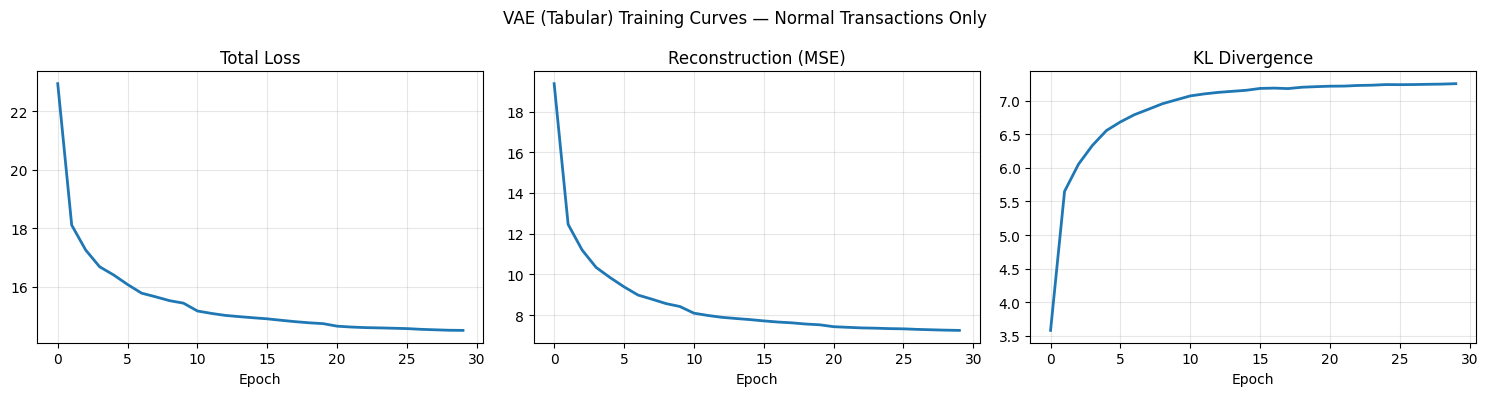

In [24]:
# Training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = ['Total Loss', 'Reconstruction (MSE)', 'KL Divergence']
keys   = ['loss', 'recon', 'kl']
for ax, lbl, key in zip(axes, labels, keys):
    ax.plot(history_tab[key], linewidth=2)
    ax.set_title(lbl); ax.set_xlabel('Epoch'); ax.grid(alpha=0.3)
fig.suptitle('VAE (Tabular) Training Curves — Normal Transactions Only', fontsize=12)
plt.tight_layout(); plt.show()

The loss curves decrease as planned. KL Divergence grows and stabilizes over time.

Now, we train two unsupervised anomaly detectors on the same training set for comparison:
- Isolation Forest - assigns an anomaly score by score_samples(), where more negative means more anomalous, so we negate it, which means higher = more anomalous.
- One-Class SVM - assigns a signed distance from the decision boundary by decision_function(), and again more negative means more anomalous, so we negate it.

In [ ]:
iso_forest = IsolationForest(n_estimators=200, contamination=0.001,
                             random_state=random_state, n_jobs=-1)
iso_forest.fit(X_train)


MAX_SVM = 20_000
rng = np.random.default_rng(random_state)
idx = rng.choice(len(X_train), size=min(MAX_SVM, len(X_train)), replace=False) # taking subset for faster computations, could affect the performance
oc_svm = OneClassSVM(kernel='rbf', nu=0.01, gamma='scale')
oc_svm.fit(X_train[idx])

OneClassSVM(nu=0.01)

Finally, we can compare our models. Each model produces an anomaly score for every test observation. Higher scores indicate higher likelihood of being fraud.

In [27]:
# VAE anomaly scores
vae_tab.eval()
X_test_t = torch.FloatTensor(X_test).to(device)

with torch.no_grad():
    x_recon_test, _, _ = vae_tab(X_test_t)
    # Per-sample MSE (mean over features)
    vae_scores = nn.functional.mse_loss(x_recon_test, X_test_t, reduction='none').mean(dim=1).cpu().numpy()

# Baseline scores
iso_scores = -iso_forest.score_samples(X_test) 
svm_scores = -oc_svm.decision_function(X_test) 

print(f'VAE scores - normal mean: {vae_scores[y_test==0].mean():.4f}  '
      f'fraud mean: {vae_scores[y_test==1].mean():.4f}')
print(f'IF  scores - normal mean: {iso_scores[y_test==0].mean():.4f}  '
      f'fraud mean: {iso_scores[y_test==1].mean():.4f}')
print(f'SVM scores - normal mean: {svm_scores[y_test==0].mean():.4f}  '
      f'fraud mean: {svm_scores[y_test==1].mean():.4f}')

VAE scores - normal mean: 0.1589  fraud mean: 2.6644
IF  scores - normal mean: 0.4019  fraud mean: 0.5739
SVM scores - normal mean: -0.7697  fraud mean: 0.5437


For each model the normal mean is lower than the fraud mean, which is obviously a good sign.

We can also visually inspect the score distributions.

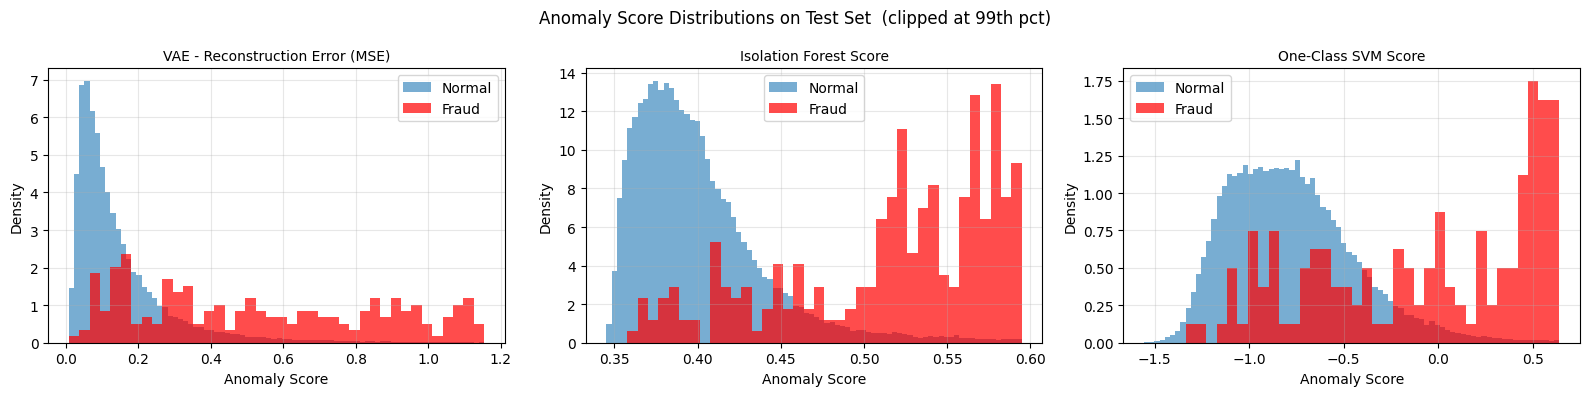

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
configs = [
    ('VAE - Reconstruction Error (MSE)', vae_scores),
    ('Isolation Forest Score', iso_scores),
    ('One-Class SVM Score', svm_scores),
]
for ax, (title, scores) in zip(axes, configs):
    p99 = np.percentile(scores, 99)
    ax.hist(scores[y_test == 0], bins=80, alpha=0.6, label='Normal', density=True,
            range=(scores.min(), p99))
    ax.hist(scores[y_test == 1], bins=40, alpha=0.7, label='Fraud',  density=True,
            range=(scores.min(), p99), color='red')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Anomaly Score'); ax.set_ylabel('Density')
    ax.legend(); ax.grid(alpha=0.3)

fig.suptitle('Anomaly Score Distributions on Test Set  (clipped at 99th pct)', fontsize=12)
plt.tight_layout(); plt.show()

With VAE we can see that the anomaly score for normal tends to be really low, and that's fine. However, the anomaly score for fraud isn't really shifted to the right side of the plot which is quite alarming. Isolation Forest and One-class SVM are not so sure with normal transactions rating, but they actually result with significantly higher scores for fraud operations.

We plot the receiver operating characteristic curve for each method and compute the area under the curve (AUC). ROC-AUC measures the probability that a randomly chosen fraud sample receives a higher anomaly score than a randomly chosen normal sample.

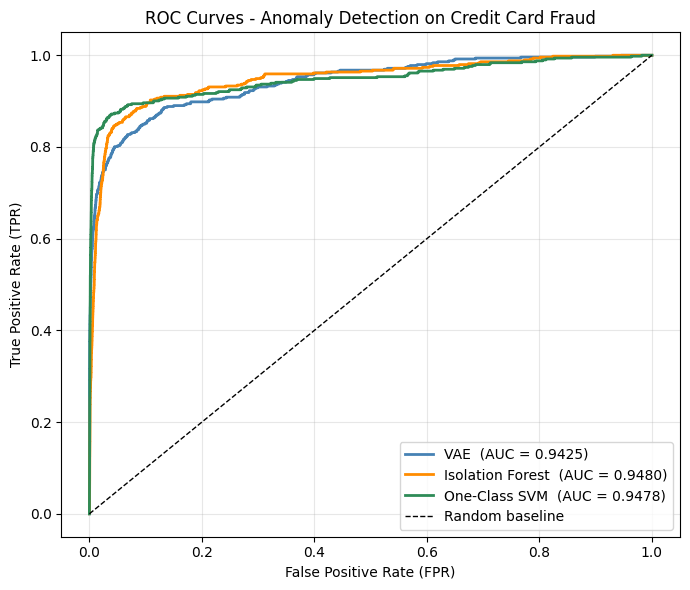

ROC-AUC scores:
  VAE                 : 0.9425
  Isolation Forest    : 0.9480
  One-Class SVM       : 0.9478


In [30]:
fig, ax = plt.subplots(figsize=(7, 6))

method_configs = [
    ('VAE',              vae_scores, 'steelblue'),
    ('Isolation Forest', iso_scores, 'darkorange'),
    ('One-Class SVM',    svm_scores, 'seagreen'),
]

for name, scores, color in method_configs:
    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name}  (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random baseline')
ax.set_xlabel('False Positive Rate (FPR)'); ax.set_ylabel('True Positive Rate (TPR)')
ax.set_title('ROC Curves - Anomaly Detection on Credit Card Fraud', fontsize=12)
ax.legend(loc='lower right', fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print('ROC-AUC scores:')
for name, scores, _ in method_configs:
    print(f'  {name:<20s}: {roc_auc_score(y_test, scores):.4f}')

On the plot, the curves represent true positive rate against the false positive rate at various threshold settings. All of the implemented methods work similarly and significantly better than the random baseline. The curves shoot straight up to roughly 0.85, which means that at the strictest anomaly score thresholds, the models are successfully catching about 85% of all actual fraud while making almost zero false alarms.

The models achieved almost equal ROC-AUC scores. ~0.94 means that if we pick one random normal transaction and one random fraudulent transaction, there is a 94% chance that the model will assign a higher anomaly score to the fraud. At first glance, it looks really well, but we need to keep in mind that ROC-AUC is deceptive on imbalanced data. In the dataset, normal transactions outnumber fraud by a massive margin. So, for example, a 5% false positive rate sounds low, but 5% of hundreds of thousands normal transactions can cause a lot of false alarms.

Because the dataset is heavily imbalanced, the PR curve is more informative than ROC. It directly measures how precisely a detector can identify the rare positive class across all decision thresholds.
- Precision - of all flagged transactions, how many are truly fraud?
- Recall - of all actual frauds, how many did we catch?

PR-AUC scores:
  VAE                 : 0.5782
  Isolation Forest    : 0.3460
  One-Class SVM       : 0.5846


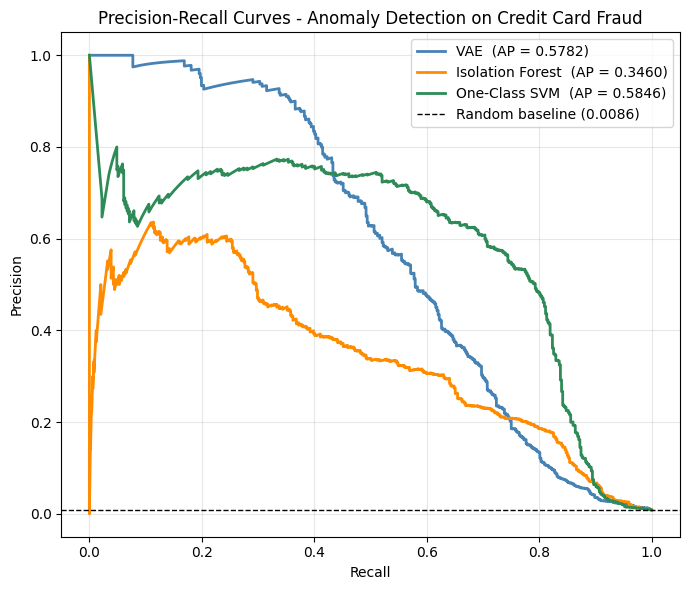

In [32]:
fig, ax = plt.subplots(figsize=(7, 6))

print('PR-AUC scores:')
for name, scores, color in method_configs:
    precision, recall, _ = precision_recall_curve(y_test, scores)
    pr_auc = average_precision_score(y_test, scores)
    ax.plot(recall, precision, color=color, linewidth=2,
            label=f'{name}  (AP = {pr_auc:.4f})')
    print(f'  {name:<20s}: {pr_auc:.4f}')

# Random baseline for imbalanced data = fraud prevalence
baseline = y_test.mean()
ax.axhline(baseline, color='k', linestyle='--', linewidth=1,
           label=f'Random baseline ({baseline:.4f})')

ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves - Anomaly Detection on Credit Card Fraud', fontsize=12)
ax.legend(loc='upper right', fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

The PR-AUC score means that, for example, if it is equal to 0.58, on average, when we flag a transaction as fraud at any threshold, there is a 58% chance it really is fraud. Even though we were worried about VAE performance, at the end it resulted with  almsot the highest PR-AUC value, being slightly behind the One-class SVM. 

When we set a strict threshold, the VAE is very reliable. It catches fraud well because it was trained exclusively on normals, so genuinely unusual transactions produce high reconstruction error. With higher recall One-class SVM keeps the highest precision across the models. Isolation forest is clearly the weakest. Precision drops sharply as soon as recall increases. It can find the most obvious frauds at very strict thresholds but sometimes struggles to separate fraud from normal transactions.